# Personalized Architecture for the Platform

In [1]:
## Standard libraries
import os
import numpy as np
import random
from PIL import Image
from types import SimpleNamespace
from pathlib import Path, PurePath

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg') # For export
import matplotlib
matplotlib.rcParams['lines.linewidth'] = 2.0
import seaborn as sns
sns.reset_orig()

## PyTorch
import torch
import torch.nn as nn
import torch.utils.data as data
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
torch.set_float32_matmul_precision('medium') # To faster math

## Lighting
import lightning as pl# Callbacks
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
# Torchvision
import torchvision
from torchvision import transforms

PyTorch Lightning is a framework that simplifies the code needed to train, evaluate, and test a model in PyTorch. It also handles logging into TensorBoard, a visualization toolkit for ML experiments, and saving model checkpoints automatically with minimal code overhead from our side. 

In [2]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    pl.seed_everything(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_seed(17)

# Ensure deterministic operations on GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print("Using device:", device)

CHECKPOINT_PATH = PurePath("../services/inference/models")

Seed set to 17


Using device: cuda:0


In [3]:
class SurfaceDefectDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data_dir = Path(data_dir)
        self.image_paths = list(self.data_dir.glob("*.jpg")) # Detect all jpgs
        self.transform = transform

        self.class_to_idx = { # Mapping classes
            'crazing': 0,
            'inclusion': 1,
            'patches': 2,
            'pitted_surface': 3,
            'rolled-in_scale': 4,
            'scratches': 5
        }

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        image = Image.open(img_path).convert('L')

        label = self.extract_label(img_path.name)

        if self.transform:
            image = self.transform(image)

        return image, label

    def extract_label(self, filename):
        class_name = filename.rsplit('_', 1)[0]
        return self.class_to_idx[class_name]


test_transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop((32,32), scale=(0.8,1.0), ratio=(0.9,1.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

batch_size = 8

trainset = SurfaceDefectDataset(
    data_dir="../data/processed/train/images",
    transform=train_transform
)

trainloader = DataLoader(
    trainset, 
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    pin_memory=True,
    num_workers=0
)

testset = SurfaceDefectDataset(
    data_dir="../data/processed/valid/images",
    transform=test_transform
)

testloader = DataLoader(
    testset, 
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=0
)

valset = SurfaceDefectDataset(
    data_dir="../data/processed/valid/images",
    transform=train_transform

)
validloader = DataLoader(
    valset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
    num_workers=0
)

classes = (
    'crazing',
    'inclusion',
    'patches',
    'pitted_surface',
    'rolled-in_scale',
    'scratches'
)

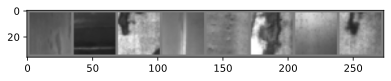

inclusion scratches patches scratches rolled-in_scale patches pitted_surface patches


In [4]:
# As in https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0))) # Similar to permute the grid
    plt.show()

images, labels = next(iter(trainloader))
imshow(torchvision.utils.make_grid(images))
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

If normalization works, the mean and std of the single batch must be close to 0 and 0.5 respectively for the channel (only one channel is in the data).

In [5]:
imgs, _ = next(iter(trainloader))
print("Batch mean", imgs.mean(dim=[0,2,3]))
print("Batch std", imgs.std(dim=[0,2,3]))

Batch mean tensor([-0.1220])
Batch std tensor([0.4295])


In [6]:
model_dict = {}

def create_model(model_name, model_hparams):
    if model_name in model_dict:
        return model_dict[model_name](**model_hparams)
    else:
        assert False, f"Unknown model name \"{model_name}\". Available models are: {str(model_dict.keys())}"

act_fn_by_name = {
    "tanh": nn.Tanh,
    "relu": nn.ReLU,
    "leakyrelu": nn.LeakyReLU,
    "gelu": nn.GELU
}

If we pass the classes or objects directly as an argument to the Lightning module, we couldn’t take advantage of PyTorch Lightning’s automatically hyperparameter saving and loading.

In [7]:
class NEUModule(pl.LightningModule):
    def __init__(
            self,
            model_name, 
            model_hparams, 
            optimizer_name, 
            optimizer_hparams
        ):
        """
        Inputs:
            model_name - Name of the model/CNN to run. Used for creating the model 
            model_hparams - Hyperparameters for the model, as dictionary.
            optimizer_name - Name of the optimizer to use. Currently supported: Adam, SGD
            optimizer_hparams - Hyperparameters for the optimizer, as dictionary. This includes learning rate, weight decay, etc.
        """
        super().__init__()
        # Exports the hyperparameters to a YAML file, and create "self.hparams" namespace
        self.save_hyperparameters()
        # Create model
        self.model = create_model(model_name, model_hparams)
        # Create loss module
        self.loss_module = nn.CrossEntropyLoss()
        # Example input for visualizing the graph in Tensorboard
        self.example_input_array = torch.zeros((1, 1, 32, 32), dtype=torch.float32)

    def forward(self, imgs):
        # Forward function that is run when visualizing the graph
        return self.model(imgs)

    def configure_optimizers(self):
        # We will support Adam or SGD as optimizers.
        if self.hparams.optimizer_name == "Adam":
            # AdamW is Adam with a correct implementation of weight decay (see here for details: https://arxiv.org/pdf/1711.05101.pdf)
            optimizer = optim.AdamW(
                self.parameters(), **self.hparams.optimizer_hparams)
        elif self.hparams.optimizer_name == "SGD":
            optimizer = optim.SGD(self.parameters(), **self.hparams.optimizer_hparams)
        else:
            assert False, f"Unknown optimizer: \"{self.hparams.optimizer_name}\""

        # We will reduce the learning rate by 0.1 after 100 and 150 epochs
        scheduler = optim.lr_scheduler.MultiStepLR(
            optimizer, milestones=[100, 150], gamma=0.1)
        return [optimizer], [scheduler]

    def training_step(self, batch, batch_idx):
        # "batch" is the output of the training data loader.
        imgs, labels = batch
        preds = self.model(imgs)
        loss = self.loss_module(preds, labels)
        acc = (preds.argmax(dim=-1) == labels).float().mean()

        # Logs the accuracy per epoch to tensorboard (weighted average over batches)
        self.log('train_acc', acc, on_step=False, on_epoch=True)
        self.log('train_loss', loss)
        return loss  # Return tensor to call ".backward" on

    def validation_step(self, batch, batch_idx):
        imgs, labels = batch
        preds = self.model(imgs).argmax(dim=-1)
        acc = (labels == preds).float().mean()
        # By default logs it per epoch (weighted average over batches)
        self.log('val_acc', acc)

    def test_step(self, batch, batch_idx):
        imgs, labels = batch
        preds = self.model(imgs).argmax(dim=-1)
        acc = (labels == preds).float().mean()
        # By default logs it per epoch (weighted average over batches), and returns it afterwards
        self.log('test_acc', acc)

In [8]:
def train_model(model_name, save_name=None, **kwargs):
    """
    Inputs:
        model_name - Name of the model you want to run. Is used to look up the class in "model_dict"
        save_name (optional) - If specified, this name will be used for creating the checkpoint and logging directory.
    """
    if save_name is None:
        save_name = model_name

    # Create a PyTorch Lightning trainer with the generation callback
    trainer = pl.Trainer(default_root_dir=os.path.join(CHECKPOINT_PATH, save_name),                          # Where to save models
                         accelerator="gpu" if str(device).startswith("cuda") else "cpu",                     # We run on a GPU (if possible)
                         devices=1,                                                                          # How many GPUs/CPUs we want to use (1 is enough for the notebooks)
                         max_epochs=50,                                                                     # How many epochs to train for if no patience is set
                         callbacks=[ModelCheckpoint(save_weights_only=True, mode="max", monitor="val_acc"),  # Save the best checkpoint based on the maximum val_acc recorded. Saves only weights and not optimizer
                                    LearningRateMonitor("epoch")],                                           # Log learning rate every epoch
                         enable_progress_bar=True)                                                           # Set to False if you do not want a progress bar
    trainer.logger._log_graph = True         # If True, we plot the computation graph in tensorboard
    trainer.logger._default_hp_metric = None # Optional logging argument that we don't need

    # Check whether pretrained model exists. If yes, load it and skip training
    pretrained_filename = os.path.join(CHECKPOINT_PATH, save_name + ".ckpt")
    if os.path.isfile(pretrained_filename):
        print(f"Found pretrained model at {pretrained_filename}, loading...")
        model = NEUModule.load_from_checkpoint(pretrained_filename) # Automatically loads the model with the saved hyperparameters
    else:
        pl.seed_everything(17) # To be reproducable
        model = NEUModule(model_name=model_name, **kwargs)
        trainer.fit(model, trainloader, testloader)
        model = NEUModule.load_from_checkpoint(trainer.checkpoint_callback.best_model_path) # Load best checkpoint after training

    # Test best model on validation and test set
    val_result = trainer.test(model, validloader, verbose=False)
    test_result = trainer.test(model, testloader, verbose=False)
    result = {"test": test_result[0]["test_acc"], "val": val_result[0]["test_acc"]}

    return model, result

The [ResNet](https://arxiv.org/abs/1512.03385) is one of the most cited AI papers, and has been the foundation for neural netowks with more than 1,000 layers. The idea of residual connections is highly effective as it supports stable gradient propagation through the network. Instead of modeling $x_{l+1}=F(x_l)$ we model $x_{l+1}=x_l + F(x_l)$ where $F$ is a non-linear mapping (usually a sequence of NN modules likes convolutions, activation functions and normalizations). If we do backpropagation on such residual connections, we obtain 
$$
\frac{\partial x_{l+1}}{\partial x_l}=\mathbf{I} + \frac{\partial F(x_l)}{\partial x_l}
$$

The bias towards the identity matrix guarantees a stable gradient propagation being less effected by $\mathbf{F}$ itself.

In [9]:
class ResNetBlock(nn.Module):
    def __init__(
            self, 
            c_in, 
            act_fn, 
            subsample=False, 
            c_out=-1
        ):
        """
        Inputs:
            c_in - Number of input features
            act_fn - Activation class constructor (e.g. nn.ReLU)
            subsample - If True, we want to apply a stride inside the block and reduce the output shape by 2 in height and width
            c_out - Number of output features. Note that this is only relevant if subsample is True, as otherwise, c_out = c_in
        """
        super().__init__()
        if not subsample:
            c_out = c_in
        
        # Network representing F
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, stride=1 if not subsample else 2, bias=False),
            nn.BatchNorm2d(c_out),
            act_fn(),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(c_out)
        )
        # 1x1 convolution with stride 2 means we take the upper left value, and transform it to new output size
        self.downsample = nn.Conv2d(c_in, c_out, kernel_size=1, stride=2) if subsample else None
        self.act_fn = act_fn()
    
    def forward(self, x):
        z = self.net(x)
        if self.downsample is not None:
            x = self.downsample(x)
        out = z + x
        out = self.act_fn(out)
        return out

The second block to implement is the pre-activation `ResNet` block. For this, we have to change the order of layer in self.net, and do not apply an activation function on the output.

In [10]:
class PreActResNetBlock(nn.Module):
    def __init__(
            self, 
            c_in, 
            act_fn,
            subsample=False,
            c_out=-1
        ):
        """
        Inputs:
            c_in - Number of input features
            act_fn - Activation class constructor (e.g. nn.ReLU)
            subsample - If True, we want to apply a stride inside the block and reduce the output shape by 2 in height and width
            c_out - Number of output features. Note that this is only relevant if subsample is True, as otherwise, c_out = c_in
        """
        super().__init__()
        if not subsample:
            c_out = c_in
        
        self.net = nn.Sequential(
            nn.BatchNorm2d(c_in),
            act_fn(),
            nn.Conv2d(c_in, c_out, kernel_size=3, padding=1, stride=1 if not subsample else 2, bias=False),
            nn.BatchNorm2d(c_out),
            act_fn(),
            nn.Conv2d(c_out, c_out, kernel_size=3, padding=1, bias=False)
        )
        # 1x1 convolution can apply non-linearity as well, but not strictly necessary
        self.downsample = nn.Sequential(
            nn.BatchNorm2d(c_in),
            act_fn(),
            nn.Conv2d(c_in, c_out, kernel_size=1, stride=2, bias=False)
        ) if subsample else None

    def forward(self, x):
        z = self.net(x)
        if self.downsample is not None:
            x = self.downsample(x)
        out = z + x
        return out

A dictionary to create a mapping from string to block class.


In [11]:
resnet_blocks_by_name = {
    "ResNetBlock": ResNetBlock,
    "PreActResNetBlock": PreActResNetBlock
}

Now the ResNet architecture

In [12]:
class ResNet(nn.Module):
    def __init__(
            self, 
            num_classes=6,
            num_blocks=[3,3,3],
            c_hidden=[16,32,64],
            act_fn_name='relu',
            block_name='ResNetBlock',
            in_channels=1,
            **kwargs):
        """
        Inputs:
            num_classes - Number of classification outputs (10 for CIFAR10)
            num_blocks - List with the number of ResNet blocks to use. The first block of each group uses downsampling, except the first.
            c_hidden - List with the hidden dimensionalities in the different blocks. Usually multiplied by 2 the deeper we go.
            act_fn_name - Name of the activation function to use, looked up in "act_fn_by_name"
            block_name - Name of the ResNet block, looked up in "resnet_blocks_by_name"
        """
        super().__init__()
        assert block_name in resnet_blocks_by_name
        self.hparams = SimpleNamespace(
            num_classes=num_classes,
            c_hidden=c_hidden,
            num_blocks=num_blocks,
            act_fn_name=act_fn_name,
            act_fn=act_fn_by_name[act_fn_name],
            block_class=resnet_blocks_by_name[block_name],
            in_channels=in_channels
        )
        self._create_network()
        self._init_params()
    
    def _create_network(self):
        c_hidden = self.hparams.c_hidden
        in_channels = self.hparams.in_channels
        # A first convolution on the original image to scale up the channel size
        if self.hparams.block_class == PreActResNetBlock:
            self.input_net == nn.Sequential(
                nn.Conv2d(in_channels, c_hidden[0], kernel_size=3, padding=1, bias=False)
            )
        else: 
            self.input_net = nn.Sequential(
                nn.Conv2d(in_channels, c_hidden[0], kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(c_hidden[0]),
                self.hparams.act_fn()
            )
        
        blocks = []
        for block_idx, block_count in enumerate(self.hparams.num_blocks):
            for bc in range(block_count):
                subsample = (bc == 0 and block_idx > 0) # Subsample first block of each group
                blocks.append(
                    self.hparams.block_class(
                        c_in=c_hidden[block_idx if not subsample else (block_idx - 1)],
                        act_fn=self.hparams.act_fn,
                        subsample=subsample,
                        c_out=c_hidden[block_idx]
                    )
                )
        self.blocks = nn.Sequential(*blocks)

        # mapping to classification output
        self.output_net = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)), # Makes the Net input agnostic!, I train in 32x32 resolution because my laptop has only 8GB of RAM, using 224x224 would use x50 more data (and so x50 more parametes)
            nn.Flatten(),
            nn.Linear(c_hidden[-1], self.hparams.num_classes)
        )
    
    def _init_params(self):
        # we should initialize the convolutions according to the activation function

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity=self.hparams.act_fn_name)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.input_net(x)
        x = self.blocks(x)
        x = self.output_net(x)
        return x
    
model_dict["ResNet"] = ResNet


In [13]:
resnet_model, resnet_results = train_model(
    model_name="ResNet",
    model_hparams={
        "num_classes": 6,
        "c_hidden": [16,32,64],
        "num_blocks": [3,3,3],
        "act_fn_name": "relu",
        "in_channels": 1
    },
    optimizer_name="SGD",
    optimizer_hparams={""
        "lr": 0.1,
        "momentum": 0.9,
        "weight_decay": 1e-4
    }
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 17
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name        ┃ Type             ┃ Params ┃ Mode  ┃  FLOPs ┃       In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ model       │ ResNet           │  271 K │ train │ 81.0 M │ [1, 1, 32, 32] │    [1, 6] │
│ 1 │ loss_module │ CrossEntropyLoss │      0 │ train │      0 │              ? │         ? │
└───┴─────────────┴──────────────────┴────────┴───────┴────────┴────────────────┴───────────┘

Trainable params: 271 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 271 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 85                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 81.0 M

Output()

c:\Users\super\anaconda3\envs\AOI\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The
'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the 
`num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.

...

c:\Users\super\anaconda3\envs\AOI\Lib\site-packages\lightning\fabric\utilities\cloud_io.py:73: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

c:\Users\super\anaconda3\envs\AOI\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

In [14]:
print("ResNet Results", resnet_results)

ResNet Results {'test': 0.6277777552604675, 'val': 0.9194444417953491}


In [17]:
%load_ext tensorboard

%tensorboard --logdir ../services/inference/models/ResNet

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Launching TensorBoard...

In future work may I use a vision transformer to check how it work with this dataset.